# Probabilistic Verification

This notebook focuses on evaluating probabilistic forecasts, typically from ensemble prediction systems.
Probabilistic metrics assess the reliability and resolution of the forecast distribution.

## Key Metrics

*   **CRPS (Continuous Ranked Probability Score)**: A proper scoring rule that generalizes MAE to probabilistic forecasts. It measures the distance between the forecast cumulative distribution function (CDF) and the empirical CDF of the observation.
*   **PIT (Probability Integral Transform)**: Checks for calibration (reliability). A perfectly calibrated ensemble should have a uniform PIT histogram.
    *   U-shape: Under-dispersive (overconfident).
    *   A-shape: Over-dispersive (underconfident).
*   **Spread-Skill Ratio**: Compares the ensemble spread (standard deviation) to the RMSE of the ensemble mean. Ideally, spread should match skill (ratio = 1).

## Relevant Code

The core logic resides in `src/swissclim_evaluations/metrics/probabilistic.py`.

Key functions:
*   [`run_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L127): Orchestrates the calculation of CRPS and PIT.
*   [`probability_integral_transform`](../src/swissclim_evaluations/metrics/probabilistic.py#L33): Computes the PIT values.
*   [`compute_wbx_crps`](../src/swissclim_evaluations/metrics/probabilistic.py#L929): Wraps WeatherBenchX CRPS calculation.

In [6]:
from pathlib import Path

import pandas as pd
import xarray as xr
from IPython.display import Image, display

from swissclim_evaluations.cli import _load_yaml, prepare_datasets, run_selected
from swissclim_evaluations.metrics.probabilistic import plot_probabilistic, run_probabilistic_wbx

In [7]:
from swissclim_evaluations.helpers import display_outputs

In [8]:
# Locate configuration relative to the notebook location
cfg_path = None
# Try to find run_full_probabilistic.yaml first, then fall back to example_config.yaml
config_names = ["run_full_probabilistic.yaml", "example_config.yaml"]

for name in config_names:
    for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        candidate = base / "config" / name
        if candidate.is_file():
            cfg_path = candidate
            print(f"Using configuration: {cfg_path}")
            break
    if cfg_path:
        break

if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config file (run_full_probabilistic.yaml or example_config.yaml) in cwd, parent, or grandparent directories."
    )

# Load configuration via project helper to keep parity with CLI
cfg = _load_yaml(cfg_path)

# Prepare datasets using the CLI pipeline (handles selection, alignment, ensemble policy)
ds_targets, ds_predictions, ds_std, ds_predictions_std = prepare_datasets(cfg)

Using configuration: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/config/example_config.yaml


In [4]:
# Show the prepared datasets (quick peek)
display(ds_targets)
display(ds_predictions)

<xarray.Dataset> Size: 2GB
Dimensions:                  (init_time: 104, lead_time: 1, latitude: 720,
                              longitude: 1440, level: 3)
Coordinates:
  * init_time                (init_time) datetime64[ns] 832B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 24B 100 500 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 832B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 431MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
    u_component_of_wind      (level, latitude, longitude, init_time, lead_time) float32 1GB dask.array<chunksize=(1, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

<xarray.Dataset> Size: 2GB
Dimensions:                  (init_time: 104, lead_time: 1, ensemble: 1,
                              latitude: 720, longitude: 1440, level: 3)
Coordinates:
  * init_time                (init_time) datetime64[ns] 832B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 8B 0
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int32 12B 100 500 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 832B 2023-...
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 431MB dask.array<chunksize=(1, 720, 1440, 1, 1), meta=np.ndarray>
    u_component_of_wind      (ensemble, level, latitude, longitude, init_time, lead_time) float32 1GB dask.array<chunksize=(1, 1, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    None

In [ ]:
# Ensure the config has probabilistic enabled
cfg_modules = cfg.get("modules", {})
if not cfg_modules.get("probabilistic", False):
    print("Enabling modules.probabilistic in-memory for this run…")
    cfg_modules["probabilistic"] = True
    cfg["modules"] = cfg_modules

# Set up output directory from config relative to project root (parent of notebooks)
project_root = Path.cwd().parent
cfg_output = cfg.get("paths", {}).get("output_root", "output/notebook_prob")
out_root = (
    (project_root / cfg_output).resolve()
    if not cfg_output.startswith("/")
    else Path(cfg_output)
)
out_root.mkdir(parents=True, exist_ok=True)
print(f"Output root: {out_root}")

# Optional: Execute the full pipeline (data prep, metrics, plots) using CLI logic.
# This will generate all configured artifacts to out_root respecting cfg['modules'] flags
# and cfg['plotting']['output_mode'] (e.g., 'npz' to export numeric data only).
RUN_ALL = False  # Set to True to run everything end-to-end automatically.

if RUN_ALL:
    run_selected(cfg)
    print(f"All selected modules executed. Outputs under: {out_root}")

Output root: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm


## CRPS Maps
Continuous Ranked Probability Score (CRPS) maps.
Shows the spatial distribution of the CRPS metric. Lower is better.

**Relevant Code:**
*   [`run_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L127): Computes CRPS summary and fields.
*   [`plot_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L344): Generates the CRPS map plots.

Displaying CRPS Maps...
--- Images in probabilistic  ---
Displaying: crps_map_10m_u_component_of_wind_init2023010200-2023010206_lead006h-006h_ensprob.png


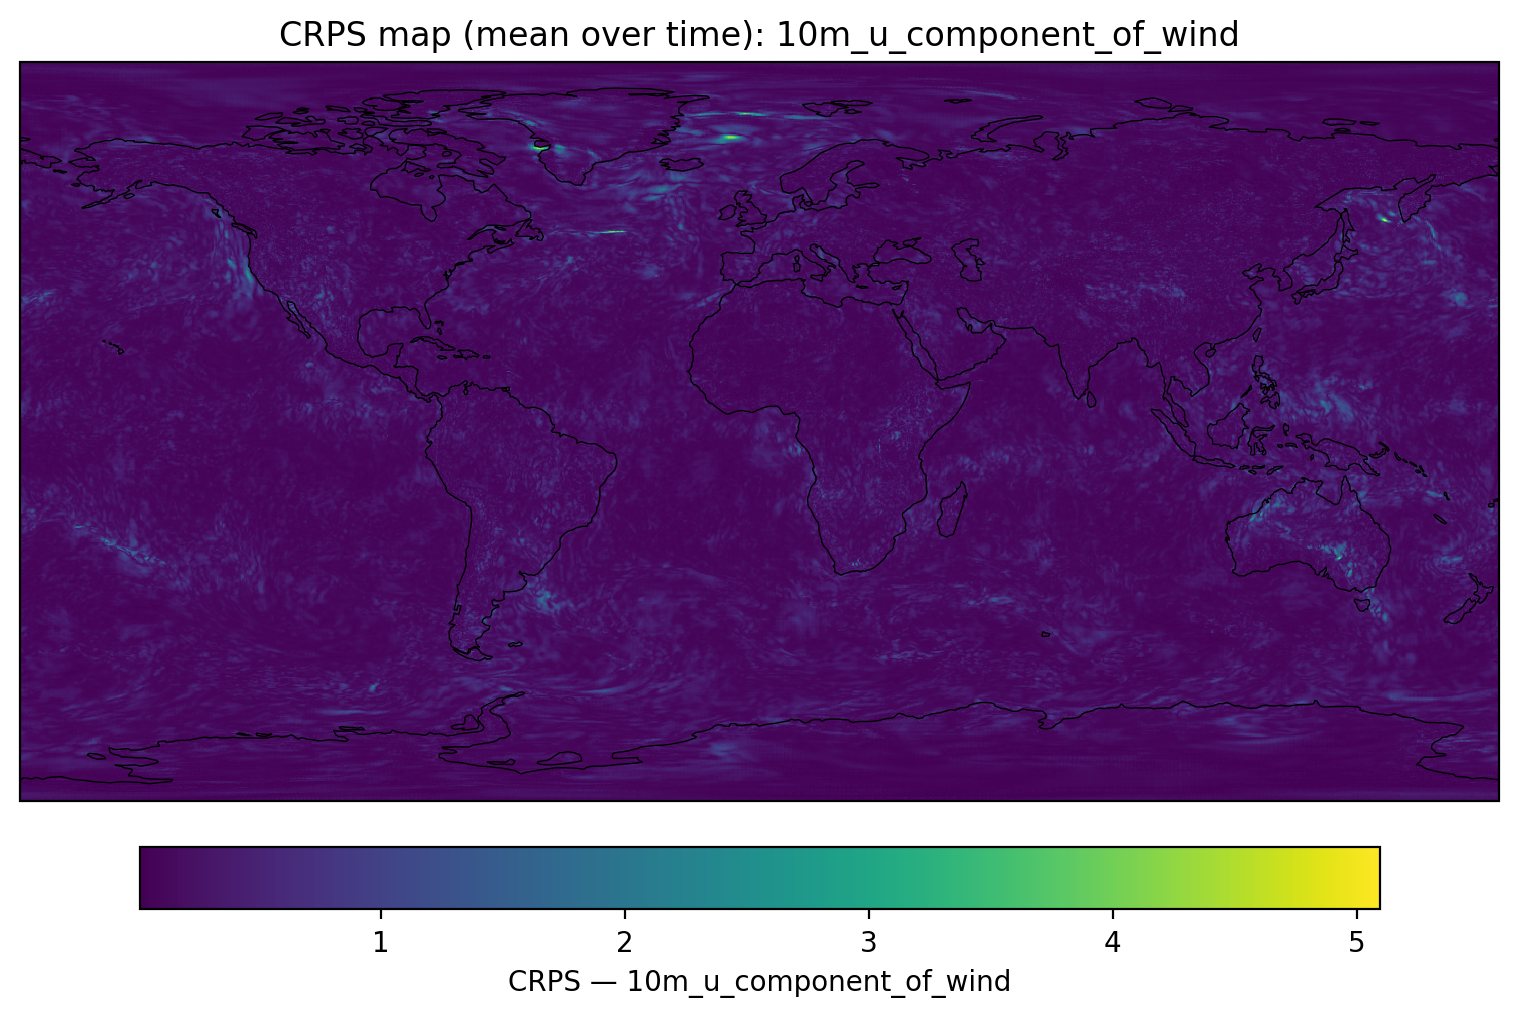

--- Tables in probabilistic ---
Table: crps_summary_averaged_init2023010200-2023010206_lead006h-006h_ensprob.csv


,variable,CRPS
0,10m_u_component_of_wind,0.190273


In [10]:
# Display CRPS Maps
print("Displaying CRPS Maps...")
display_outputs(out_root / "probabilistic", pattern_img="crps_map_*.png", pattern_csv="crps_summary*.csv")

## PIT Histograms
Probability Integral Transform (PIT) histograms.
Checks for calibration. A flat histogram indicates a well-calibrated ensemble.
U-shape indicates under-dispersion (overconfident).
Inverted U-shape indicates over-dispersion (underconfident).

**Relevant Code:**
*   [`probability_integral_transform`](../src/swissclim_evaluations/metrics/probabilistic.py#L33): Computes the PIT values.
*   [`plot_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L344): Generates the PIT histogram plots.

Displaying PIT Histograms...
--- Images in probabilistic  ---
Displaying: pit_hist_10m_u_component_of_wind.png


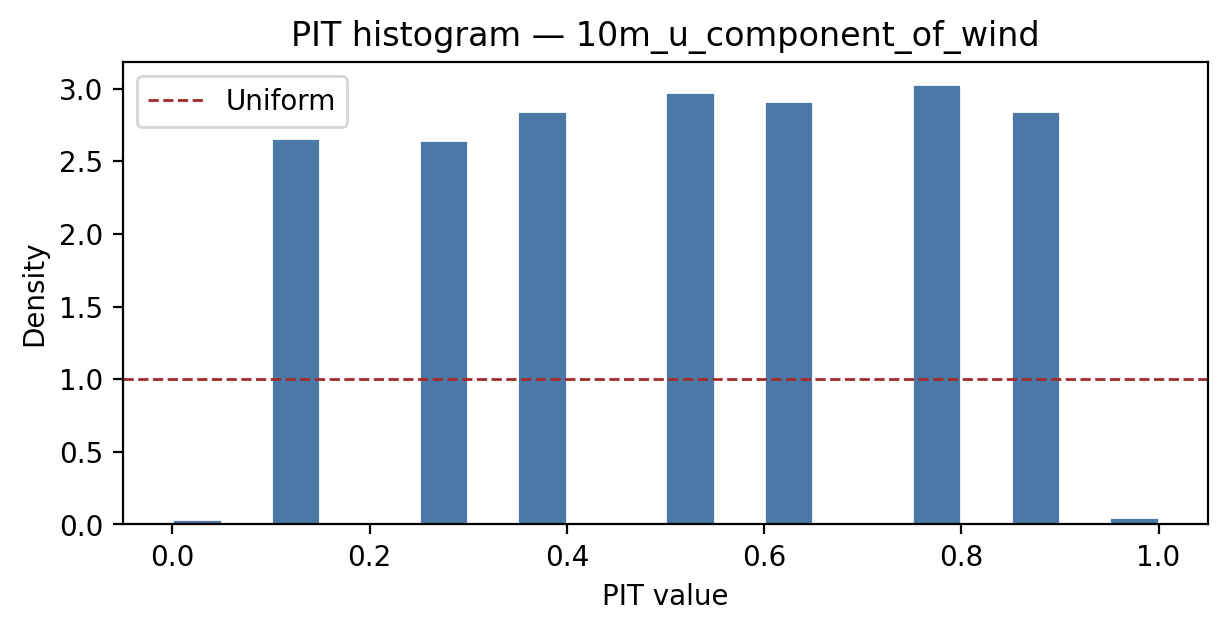

No tables found for pattern 'None' in probabilistic


In [11]:
# Display PIT Histograms
print("Displaying PIT Histograms...")
display_outputs(out_root / "probabilistic", pattern_img="pit_hist_*.png", pattern_csv="None")

## Spread-Error Diagrams
Compares the ensemble spread (standard deviation) with the RMSE of the ensemble mean.
For a well-calibrated ensemble, spread should match the error.

**Relevant Code:**
*   [`run_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L127): Calculates Spread-Skill Ratio.
*   [`plot_probabilistic`](../src/swissclim_evaluations/metrics/probabilistic.py#L344): Generates the Spread-Error diagrams.

Displaying Spread-Error Diagrams...
No images found for pattern 'spread_error_*.png' in probabilistic
--- Tables in probabilistic ---
Table: spread_skill_ratio_init2023010200-2023010206_lead006h-006h_ensprob.csv


,variable,SSR
0,10m_u_component_of_wind,NaN


Displaying SSR Temporal Plots...
--- Images in probabilistic  ---
Displaying: ssr_temporal_SSR.10m_u_component_of_wind_init2023010200-2023010206_lead006h-006h_ensprob.png


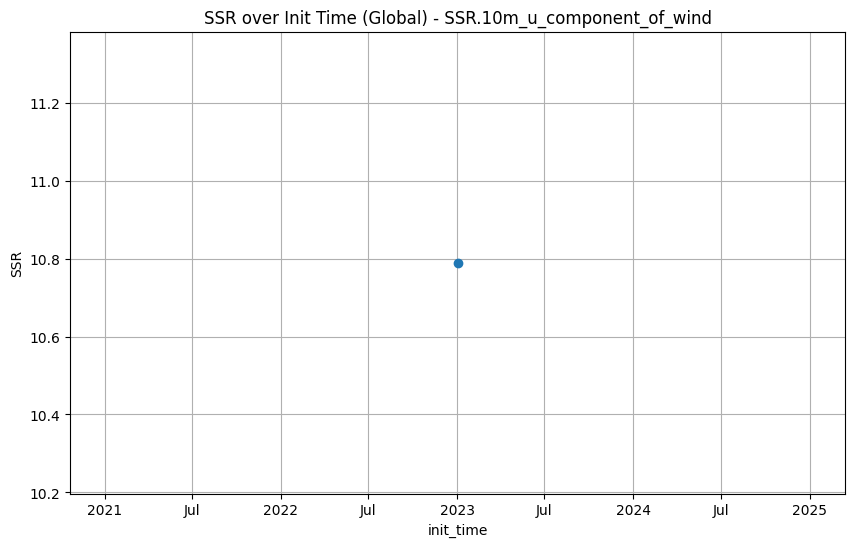

No tables found for pattern 'None' in probabilistic
Displaying SSR Spatial Plots...
--- Images in probabilistic  ---
Displaying: ssr_spatial_SSR.10m_u_component_of_wind_init2023010200-2023010206_lead006h-006h_ensprob.png


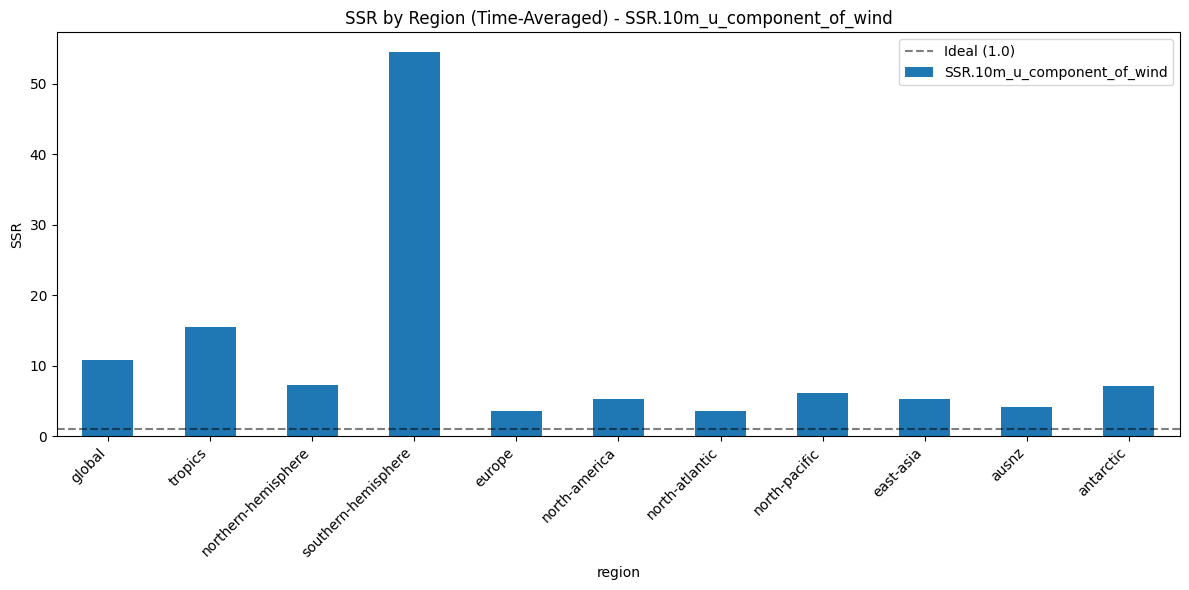

No tables found for pattern 'None' in probabilistic


In [8]:
# Display Spread-Error Diagrams
print("Displaying Spread-Error Diagrams...")
display_outputs(out_root / "probabilistic", pattern_img="spread_error_*.png", pattern_csv="spread_skill*.csv")

# Display SSR Temporal Plots
print("Displaying SSR Temporal Plots...")
display_outputs(out_root / "probabilistic", pattern_img="ssr_temporal_*.png", pattern_csv="None")

# Display SSR Spatial Plots
print("Displaying SSR Spatial Plots...")
display_outputs(out_root / "probabilistic", pattern_img="ssr_spatial_*.png", pattern_csv="None")

Loaded: prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc


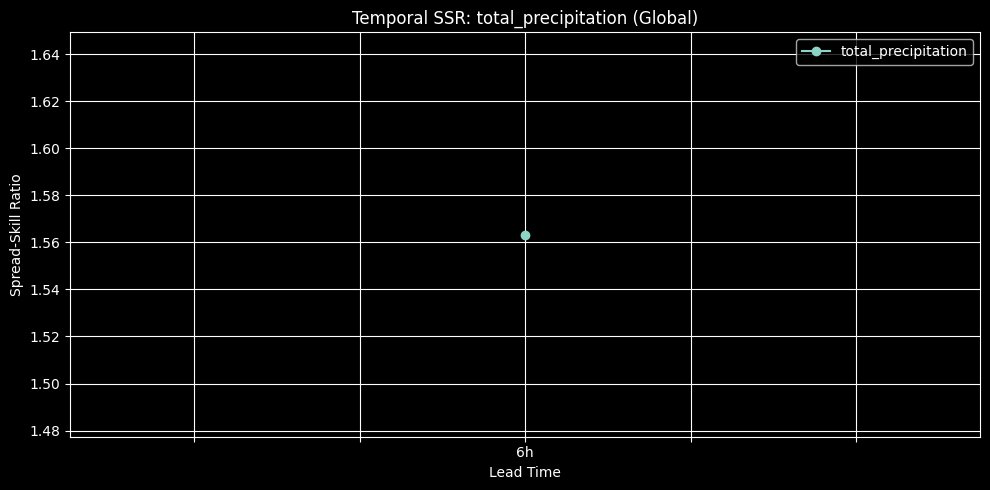

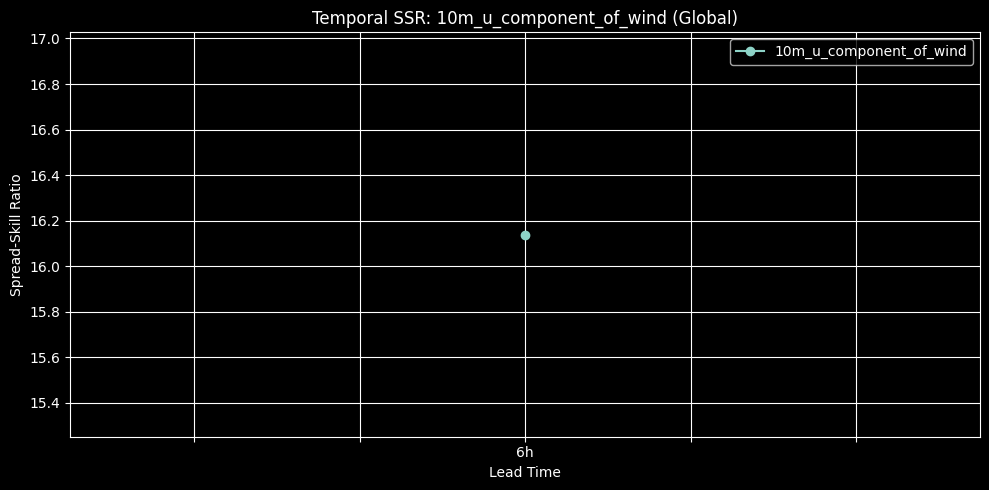

In [12]:
# Read temporal results (metrics vs lead_time)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = ["prob_metrics_temporal_*.nc"]

candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds = xr.load_dataset(fn, engine="scipy")
    print(f"Loaded: {fn.name}")
    
    # Clean up variable names (remove SSR. prefix)
    new_names = {v: v.replace("SSR.", "") for v in ds.data_vars}
    ds = ds.rename(new_names)
    
    # Format lead_time to hours strings for nicer plotting
    if "lead_time" in ds.coords:
        lt = ds.coords["lead_time"]
        # Check if timedelta (ns)
        if lt.dtype.kind == 'm':
            hours = (lt.values / np.timedelta64(1, 'h')).astype(int)
            ds = ds.assign_coords(lead_time=[f"{h}h" for h in hours])
        # Check if numeric
        elif lt.dtype.kind in 'iu':
            ds = ds.assign_coords(lead_time=[f"{int(h)}h" for h in lt.values])

    # Iterate over each variable to create a separate plot
    for var_name in ds.data_vars:
        da = ds[var_name]
        
        # Heuristic: Fix 2D variables that might have a 'level' dimension artifact
        # If it's a surface variable, we collapse the level dimension
        is_2d = var_name.startswith(("10m_", "2m_", "mean_sea_level_pressure"))
        if is_2d and "level" in da.dims:
            da = da.mean("level") # Collapse levels for 2D vars
            
        # Focus on 'global' region for temporal evolution, or mean if global missing
        if "region" in da.dims:
            if "global" in da["region"].values:
                da_plot = da.sel(region="global")
                title_suffix = "(Global)"
            else:
                da_plot = da.mean("region")
                title_suffix = "(Region Mean)"
        else:
            da_plot = da
            title_suffix = ""
            
        # Average over init_time if present
        if "init_time" in da_plot.dims:
            da_plot = da_plot.mean("init_time")
            
        # Convert to dataframe for plotting
        # da_plot dims: lead_time, (level)
        df = da_plot.to_dataframe(name=var_name)
        
        # If level exists, unstack to show levels as separate columns (lines)
        if "level" in df.index.names:
            df = df.unstack("level")
            # Columns become MultiIndex (var_name, level). Drop var_name.
            df.columns = df.columns.droplevel(0)
        
        # Plot
        ax = df.plot(kind="line", figsize=(10, 5), marker="o")
        ax.set_title(f"Temporal SSR: {var_name} {title_suffix}")
        ax.set_xlabel("Lead Time")
        ax.set_ylabel("Spread-Skill Ratio")
        ax.grid(True)
        
        # Clean up legend
        ax.legend(title="Level (hPa)" if "level" in da.dims and not is_2d else None)
        
        plt.tight_layout()
        plt.show()
else:
    print("No temporal metrics found.")

Loaded: prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc


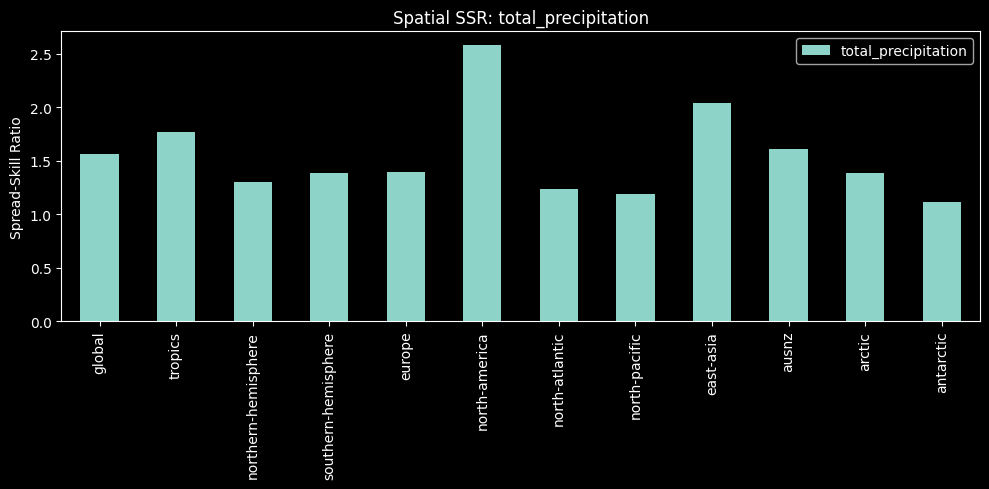

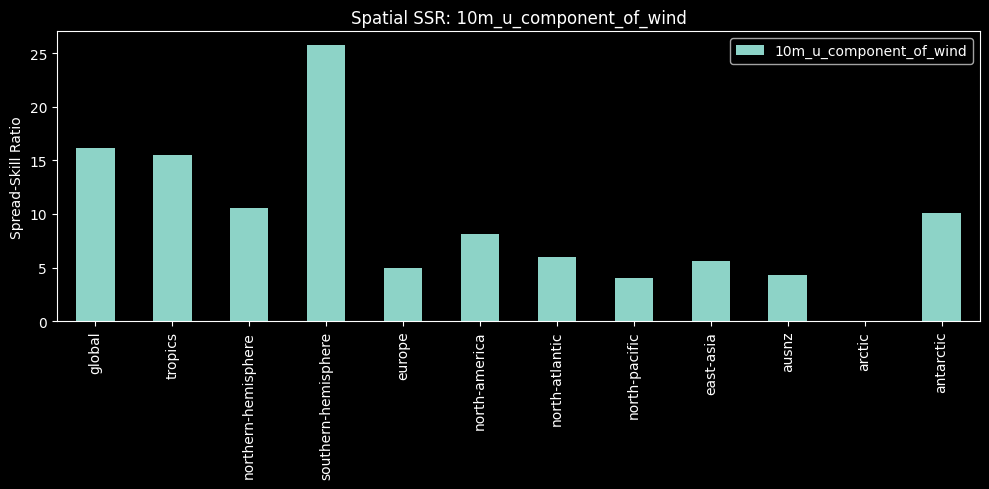

In [13]:
# Read spatial results (metrics vs region)
# Note: We use the 'temporal' file because it contains the region dimension (binned spatial data)
# The 'spatial' file contains full lat/lon grids which are better viewed as maps.

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = ["prob_metrics_temporal_*.nc"] # Use temporal file for regions!

candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds = xr.load_dataset(fn, engine="scipy")
    print(f"Loaded: {fn.name}")
    
    # Clean up variable names (remove SSR. prefix)
    new_names = {v: v.replace("SSR.", "") for v in ds.data_vars}
    ds = ds.rename(new_names)
    
    if "region" in ds.dims:
        # Iterate over each variable
        for var_name in ds.data_vars:
            da = ds[var_name]
            
            # Heuristic: Fix 2D variables that might have a 'level' dimension artifact
            is_2d = var_name.startswith(("10m_", "2m_", "mean_sea_level_pressure"))
            if is_2d and "level" in da.dims:
                da = da.mean("level")

            # Average over time (init_time, lead_time)
            dims_to_mean = [d for d in ["init_time", "lead_time"] if d in da.dims]
            da_plot = da.mean(dims_to_mean)
            
            # Convert to dataframe
            df = da_plot.to_dataframe(name=var_name)
            
            # If level exists, unstack
            if "level" in df.index.names:
                df = df.unstack("level")
                df.columns = df.columns.droplevel(0)
                
            ax = df.plot(kind="bar", figsize=(10, 5))
            ax.set_title(f"Spatial SSR: {var_name}")
            ax.set_xlabel("") # Remove Region label as requested
            ax.set_ylabel("Spread-Skill Ratio")
            
            # Clean up legend
            ax.legend(title="Level (hPa)" if "level" in da.dims and not is_2d else None)
            
            plt.tight_layout()
            plt.show()
    else:
        print("No 'region' dimension found in metrics file.")
else:
    print("No metrics found.")

In [14]:
# Read CSV summaries (SSR and CRPS ensemble) with robust discovery
module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
# Map logical names to filename patterns we accept
csv_patterns = {
    "spread_skill_ratio": ["spread_skill_ratio.csv", "spread_skill_ratio_*.csv"],
    "crps_ensemble": ["crps_ensemble.csv", "crps_ensemble_*.csv"],
}

for label, patterns in csv_patterns.items():
    candidates = []
    for md in module_dirs:
        if md.exists():
            for pat in patterns:
                candidates.extend(md.glob(pat))

    if candidates:
        p = max(candidates, key=lambda x: x.stat().st_mtime)
        try:
            df = pd.read_csv(p)
            print(f"Loaded {label}:", p)
            display(df.head(10))
        except Exception as e:
            print(f"Failed reading {p}: {e}")
    else:
        searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
        print(f"Not found {label} under: {searched}")

Loaded spread_skill_ratio: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm_probabilistic_full_all_times/probabilistic/spread_skill_ratio_init2023010200-2023010812_lead006h-006h_ensprob.csv


,variable,SSR
0,10m_u_component_of_wind,NaN
1,total_precipitation,1.509076


Not found crps_ensemble under: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm_probabilistic_full_all_times/probabilistic
